# Bending Fitting Function Explained
This notebook takes from a similar format as the Bending_algebra.ipynb notebook but to explain the steps behind the actual bending mode fit calculation or commonly known as the modalCorrection function.

## Setup of environment/coordinates

In [86]:
from pathlib import Path

import numpy as np
import psd_utils
from matplotlib import pyplot as plt
from scipy.interpolate import griddata

from rfcml_bending import Bending
from rfcml_bending.force_matrix import ForceSpace

maxBendingModes = 10 # defining some arbitary number of bending modes

## Define the inputs for the function

In order to perform a bending mode fit, we need to read in the matrices from the forceSpace file that are results from SVD. For our function, we will define three main inputs.
* forceSpace - data set with matrices from SVD done on interaction matrix of the mirror. 
* mapOnFEGrid - resampled input surface data or unknown that we are trying to fit bending modes to.
* t - number of bending modes defined. 

The number of actuators corresponds to the number of columns in matrix U or the bending mode matrix. So we defined the actuators by the number of columns in the bending mode matrix. 

Define the maximum number of bending modes we are fitting to as the input of our function. 

For the purpose of demonstrating the fit calculation int his notebook, we are just going to fit a bending mode to itself.

After the parameters are set for the fitting function, we mask our input surface map to only index finite values to avoid any NaNs or Inf values. 

Our input surface map is originally a 2D matrix with the shape $N$ x $N$. With resampling done earlier in the fitting code, we interpolate to then be $N^2$ x 1. This is to fit our input surface to the dictionary of bending modes as defined by matrix $U$.



We then define a loop to go through each bending mode and perform a fitting. The loop then goes through the following steps for each bending mode. We will define the number of bending modes as $f$.

1. Populate a stiffness matrix at the $f$ x $f$ position with the inverse of the $S$ matrix from SVD calculation. 
2. The 'bendCoef' variable defined in the fit is calculated by multiplying the transpose of the $U$ matrix taking only the columns up to the number of bending modes $f$ defined. The dimensions of this calculation are [$f$ x $N^2$] x [$N^2$ x 1]. The resulting matrix is [$f$ x 1] which is an array representing how much of each mode are present in the input surface data. 
3. Now we reconstruct the mode given the input surface map information by multiplying the columns of the $U$ matrix up to the amount of bending modes that are being fitted by the 'bendCoef'. The dimensions of this calculation is [$N^2$ x $f$] x [$f$ x 1] so the resulting matrix is [$N^2$ x 1] and we can interpolate back from a 1D array to 2D array.

As for calculating the forces associated with the number of bending modes being fit to the input surface map we multiply the $V$ matrix from SVD by the inverse $S$ matrix. The 'bendCoef' array is also multiplied by the stiffness matrix up to how many bending modes are being fit to to get how much force is being is being applied to each actuator from the bending mode fit.
$F$ $=$ [$166$ x $166$] x [$166$ x $f$] x [$f$ x 1] 

The resulting matrix $F$ has dimensions of [$166$ x 1] which represents how much of force is applied by each actuator for that given bending mode. 166 represents the amount of actuators that are available on the mirror and can be changed depending on what mirror is being used.



Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 0)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 1)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 2)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 3)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 4)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 5)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 6)
Input surface shape: (17058,)
Stiffness matrix shape: (166, 166)
bendCoef matrix shape: ()
forces matrix shape: (166, 7)
Input surface shape: (17058,)
St

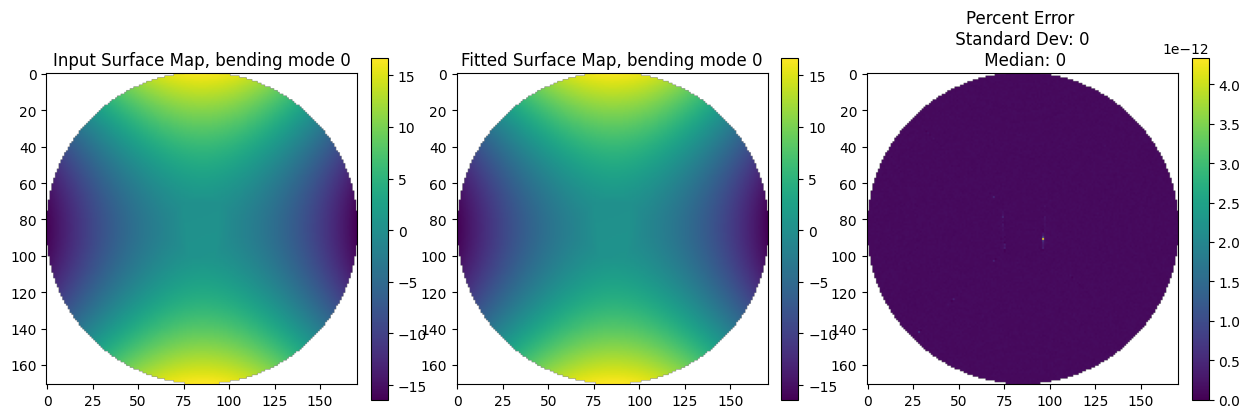

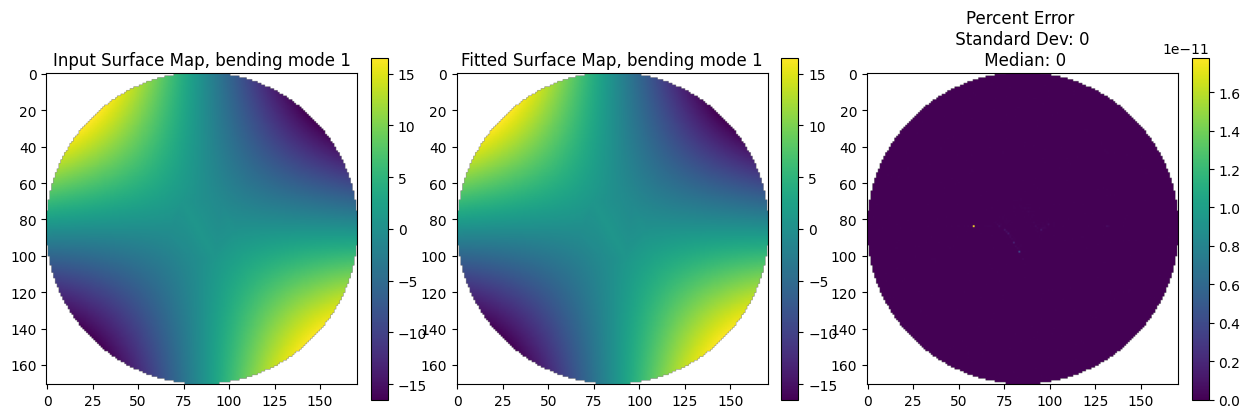

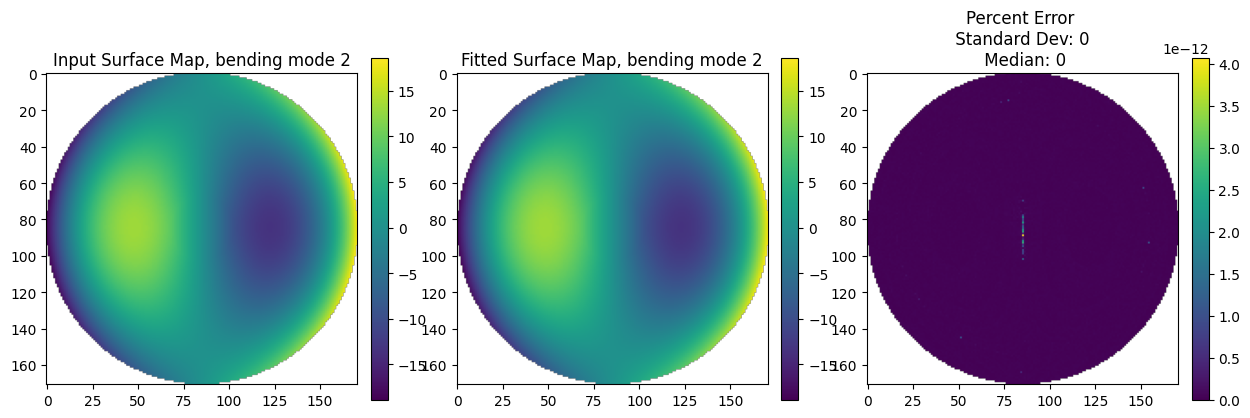

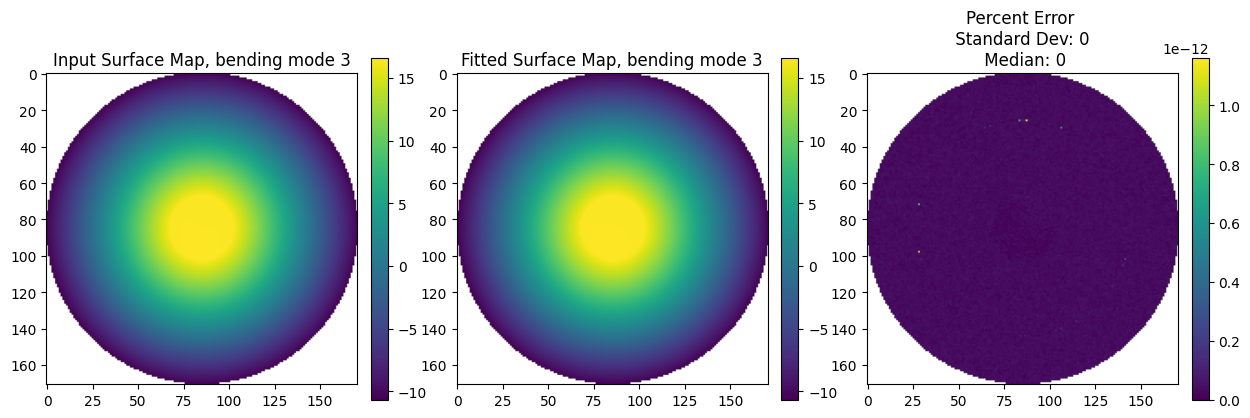

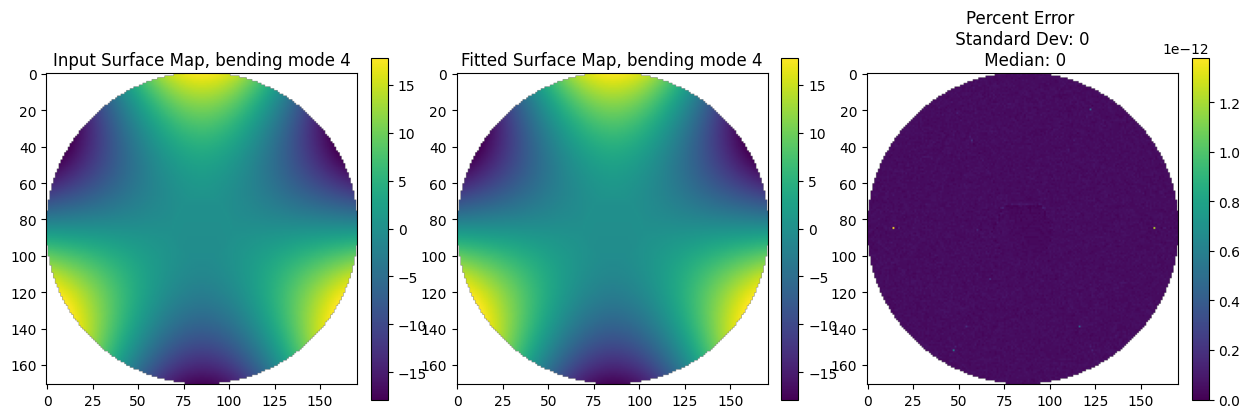

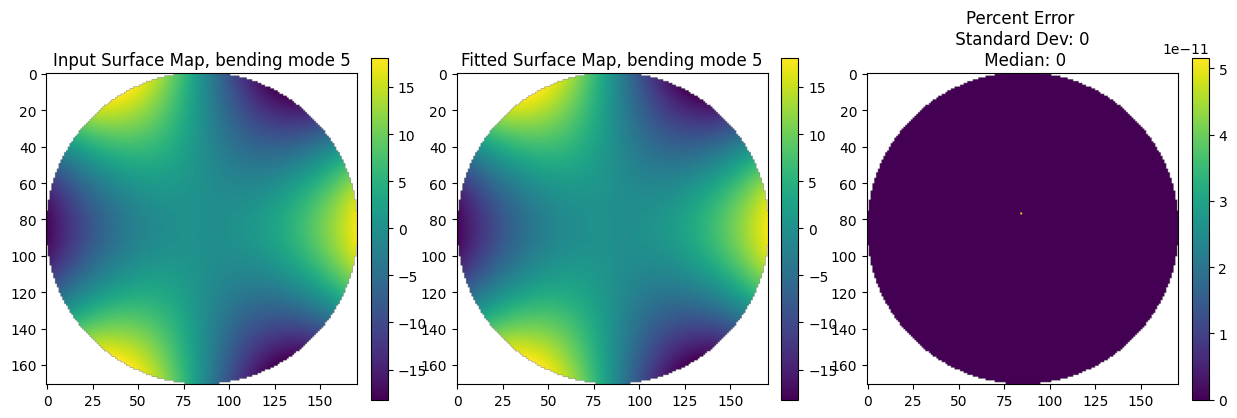

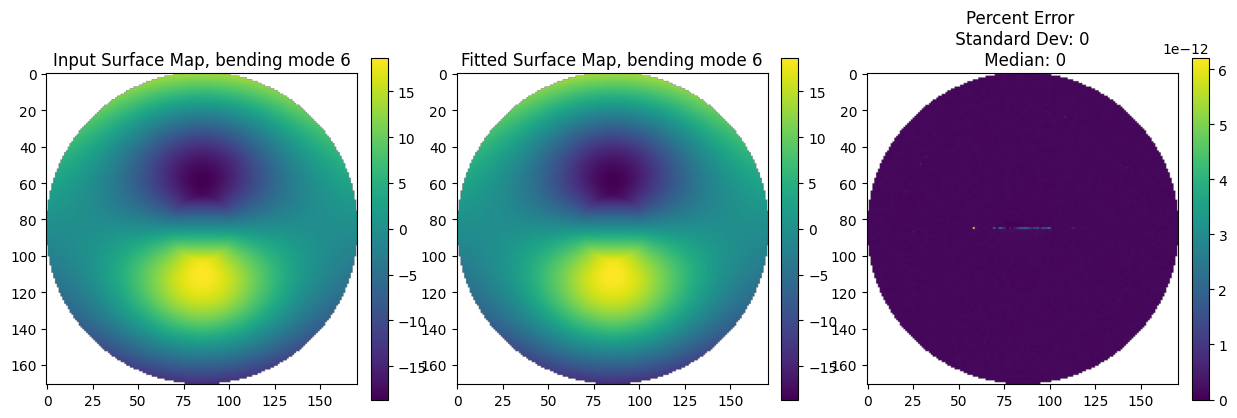

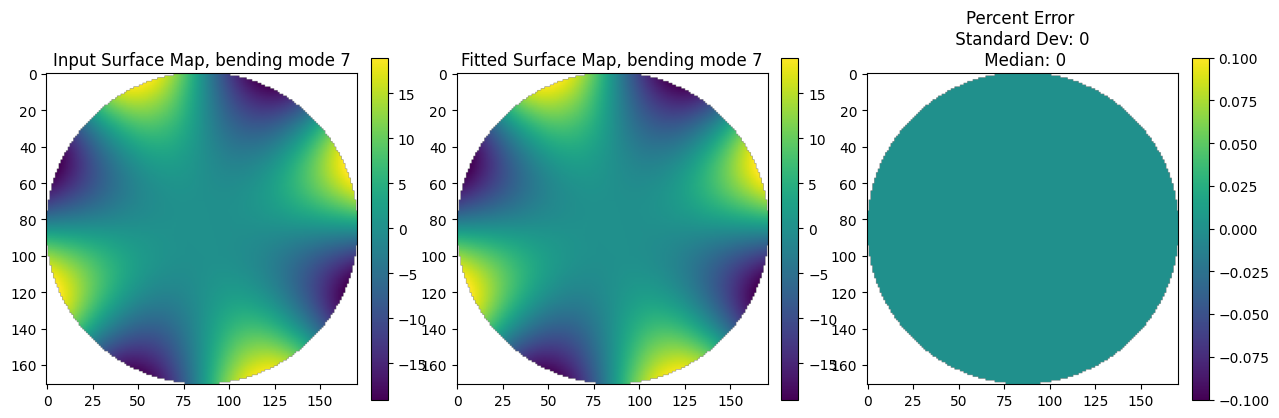

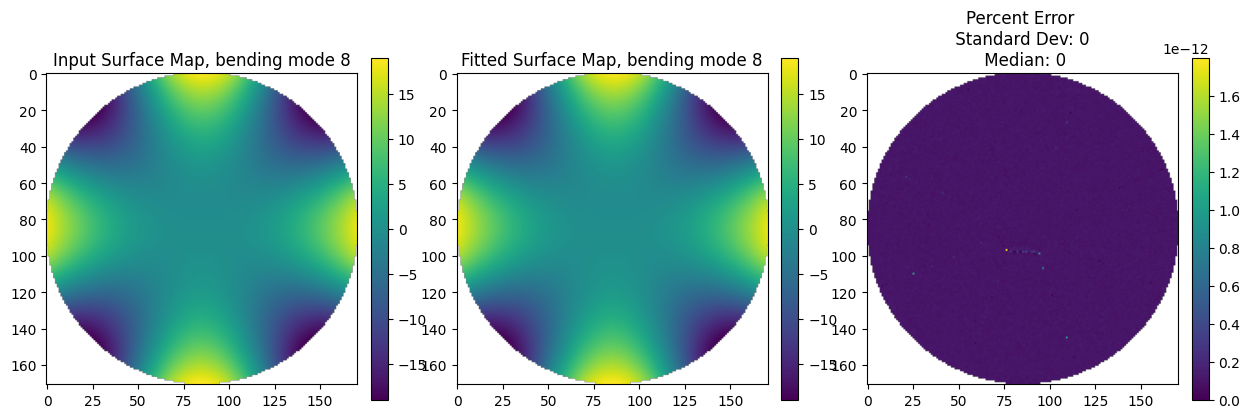

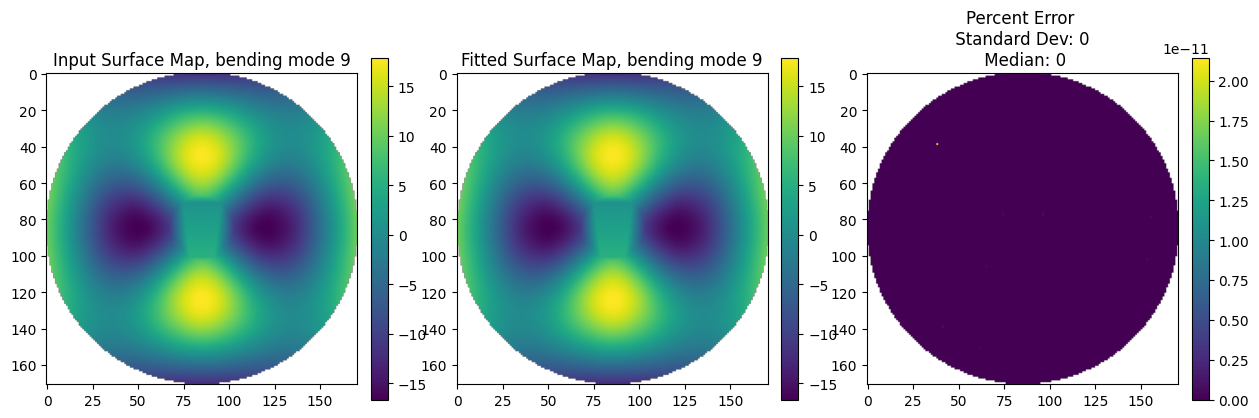

In [92]:
file_path = Path("C:/Users/solva/OneDrive - University of Arizona/Desktop/bending_mode/stp_forcespace_RW_220928.mat")
force_space = ForceSpace(file_path)
#print(force_space.data['U'])

for f in range(maxBendingModes):
    actuators = force_space.data['U'].shape[1]
    sinv = np.zeros((actuators, actuators))


    mapOnFEGrid = force_space.data['U'][:, f]*1000
    maskOnFEgrid = np.isfinite(mapOnFEGrid)
    #print(mapOnFEGrid[maskOnFEgrid])

    print(f"Input surface shape: {mapOnFEGrid.shape}")

    sinv[f, f] = 1.0/ force_space.data['S'][f, f] # Create a stiffness matrix

    print(f"Stiffness matrix shape: {sinv.shape}")

    bendCoef = np.dot(force_space.data['U'][:, f].T, mapOnFEGrid[maskOnFEgrid])
    #print(bendCoef)
    print(f"bendCoef matrix shape: {bendCoef.shape}")

    forceCoef = np.dot(sinv[:, :f], bendCoef) # Multiply each bending mode coefficient by the stiffness to get how much of each force mode
    forces = np.dot(force_space.data['V'], forceCoef) # Convert from force modes to actuator forces
    print(f"forces matrix shape: {forces.shape}")

    #rmsForces = np.sqrt(np.dot(forces, forces) / actuators) # Calculate RMS force of all actuator forces across the mirror

    #forces_bal = np.dot(force_space.data['RW_af2lc'], forces) 
    #forces_bal =  -forces_bal
    #rmsForces_bal = np.sqrt(np.dot(forces_bal, forces_bal) / actuators)

    zModeFit = np.dot(force_space.data['U'][:, f], bendCoef)
    fit = zModeFit 

    psd_tools = psd_utils.PSDUtils()

    dims = (171, 171)
    xrange = np.max(force_space.data["x_nodes"]) - np.min(force_space.data["y_nodes"])
    n_nodes = len(force_space.data["x_nodes"])
    dx = xrange / dims[0]
    coords = psd_tools.coord_arrays(dims, dx=dx, offset_x=0, offset_y=0)

    b_mode = force_space.fea_to_grid(mapOnFEGrid, coords=coords, method="linear")

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(b_mode)
    plt.colorbar(fraction=0.05, pad=0.04)
    plt.title(f"Input Surface Map, bending mode {f}")

    b_mode_fit = force_space.fea_to_grid(fit, coords=coords, method="linear")

    plt.subplot(1, 3, 2)
    plt.imshow(b_mode_fit)
    plt.colorbar(fraction=0.05, pad=0.04)
    plt.title(f"Fitted Surface Map, bending mode {f}")

    # calculating percent error map
    percen_err = np.abs((b_mode_fit - b_mode) / (b_mode)) * 100

    perc_stddev = np.nanstd(percen_err)
    perc_med = np.nanmedian(percen_err)


    plt.subplot(1,3, 3)
    plt.imshow(percen_err)
    plt.colorbar(fraction=0.05, pad=0.04)
    plt.title(f"Percent Error \n Standard Dev: {round(perc_stddev)} \n Median: {round(perc_med)}")

